## 1) Notebook imports + helper settings

In [1]:
# Cell 1 — imports and notebook config
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# nicer default figures
plt.rcParams.update({"figure.figsize": (8,5), "figure.dpi": 120})
pd.set_option("display.max_columns", 50)


## 2) Load files (u.data, u.item, u.user)

In [15]:
# Cell 2 — load MovieLens 100k files
base = "../data/ml-100k/ml-100k"

ratings = pd.read_csv(
    os.path.join(base, "u.data"),
    sep="\t",
    names=["userId", "movieId", "rating", "timestamp"],
    engine="python"
)

movies = pd.read_csv(
    os.path.join(base, "u.item"),
    sep="|",
    header=None,
    encoding="latin-1",
    names=["movieId", "title", "release_date", "video_release_date", "IMDb_URL"]
          + [f"genre_{i}" for i in range(19)]
)

users = pd.read_csv(
    os.path.join(base, "u.user"),
    sep="|",
    names=["userId", "age", "gender", "occupation", "zip_code"]
)

print("ratings:", ratings.shape)
print("movies:", movies.shape)
print("users:", users.shape)

ratings.head()


ratings: (100000, 4)
movies: (1682, 24)
users: (943, 5)


,userId,movieId,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


## 3) Basic summary & rating distribution

Unique users: 943
Unique movies: 1682
Total ratings: 100000

Rating counts:
 rating
1     6110
2    11370
3    27145
4    34174
5    21201
Name: count, dtype: int64


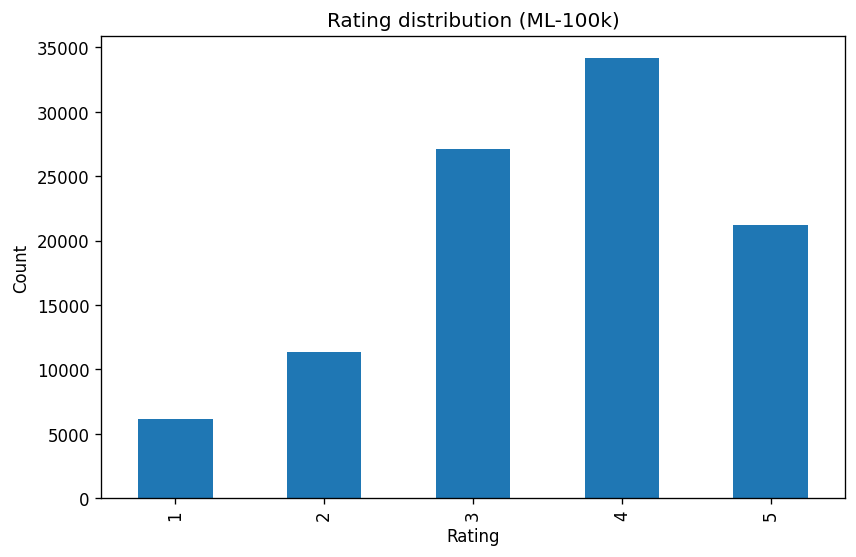

In [16]:
# Cell 3 — basic stats and rating distribution
print("Unique users:", ratings['userId'].nunique())
print("Unique movies:", ratings['movieId'].nunique())
print("Total ratings:", len(ratings))

# rating distribution
counts = ratings['rating'].value_counts().sort_index()
print("\nRating counts:\n", counts)

# Plot distribution
counts.plot(kind='bar')
plt.title("Rating distribution (ML-100k)")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


## 4) Top-rated & most-rated movies (with minimum-ratings filter)

In [17]:
# Cell 4 — top rated and most rated
# join movie titles
ratings_with_titles = ratings.merge(movies[['movieId','title']], on='movieId', how='left')

# compute counts and mean
movie_stats = ratings_with_titles.groupby(['movieId','title'])['rating'].agg(['count','mean']).reset_index()
movie_stats = movie_stats.rename(columns={'count':'num_ratings','mean':'avg_rating'})

# Most-rated movies
most_rated = movie_stats.sort_values('num_ratings', ascending=False).head(15)
print("Most rated movies (top 15):")
display(most_rated)

# Top-rated movies with at least 50 ratings (to avoid tiny-sample artifacts)
top_rated = movie_stats[movie_stats['num_ratings']>=50].sort_values('avg_rating', ascending=False).head(15)
print("Top rated movies (>=50 ratings):")
display(top_rated)


Most rated movies (top 15):


,movieId,title,num_ratings,avg_rating
49,50,Star Wars (1977),583,4.358491
257,258,Contact (1997),509,3.803536
99,100,Fargo (1996),508,4.155512
180,181,Return of the Jedi (1983),507,4.007890
293,294,Liar Liar (1997),485,3.156701
285,286,"English Patient, The (1996)",481,3.656965
287,288,Scream (1996),478,3.441423
0,1,Toy Story (1995),452,3.878319
299,300,Air Force One (1997),431,3.631090
120,121,Independence Day (ID4) (1996),429,3.438228


Top rated movies (>=50 ratings):


,movieId,title,num_ratings,avg_rating
407,408,"Close Shave, A (1995)",112,4.491071
317,318,Schindler's List (1993),298,4.466443
168,169,"Wrong Trousers, The (1993)",118,4.466102
482,483,Casablanca (1942),243,4.456790
113,114,Wallace & Gromit: The Best of Aardman Animatio...,67,4.447761
63,64,"Shawshank Redemption, The (1994)",283,4.445230
602,603,Rear Window (1954),209,4.387560
11,12,"Usual Suspects, The (1995)",267,4.385768
49,50,Star Wars (1977),583,4.358491
177,178,12 Angry Men (1957),125,4.344000


## 5) Visualize top-rated and most-rated (barplots)

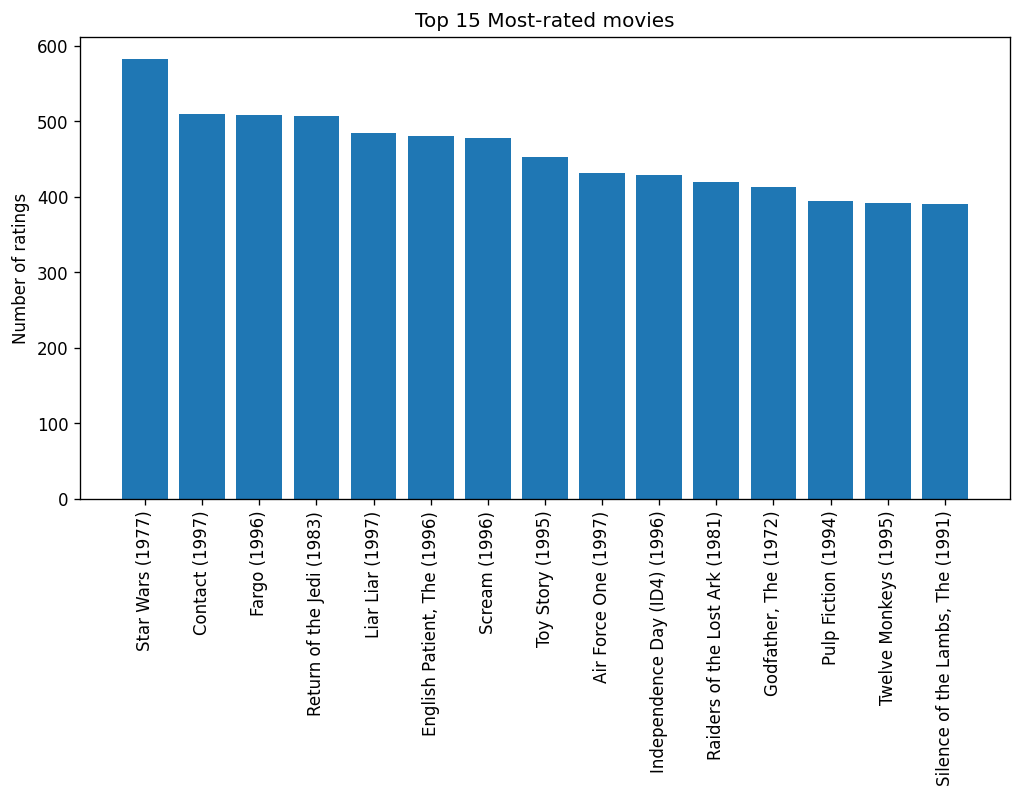

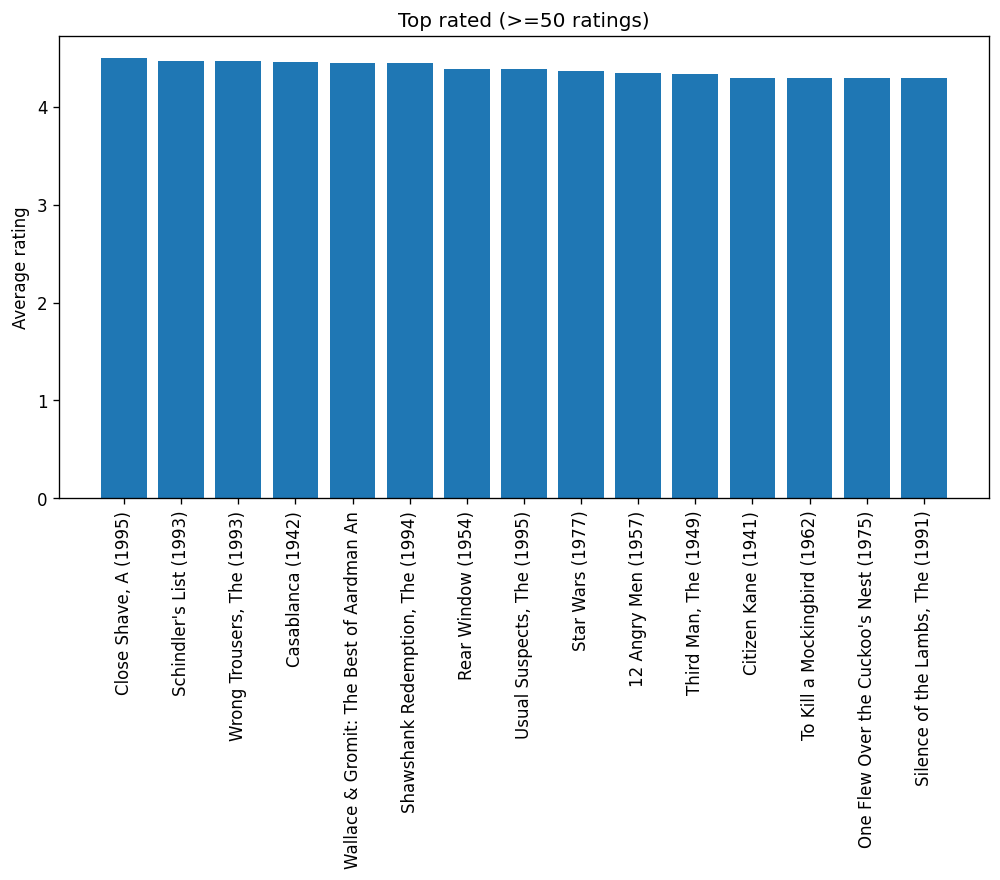

In [18]:
# Cell 5 — visualization
plt.figure(figsize=(10,5))
plt.bar(most_rated['title'].str[:40], most_rated['num_ratings'])
plt.xticks(rotation=90)
plt.title("Top 15 Most-rated movies")
plt.ylabel("Number of ratings")
plt.show()

plt.figure(figsize=(10,5))
plt.bar(top_rated['title'].str[:40], top_rated['avg_rating'])
plt.xticks(rotation=90)
plt.title("Top rated (>=50 ratings)")
plt.ylabel("Average rating")
plt.show()


## 6) Genres frequency

unknown        725
Action         505
Adventure      251
Animation      251
Children's     247
Comedy         135
Crime          122
Documentary    109
Drama          101
Fantasy         92
Film-Noir       71
Horror          61
Musical         56
Mystery         50
Romance         42
Sci-Fi          27
Thriller        24
War             22
Western          2
dtype: int64


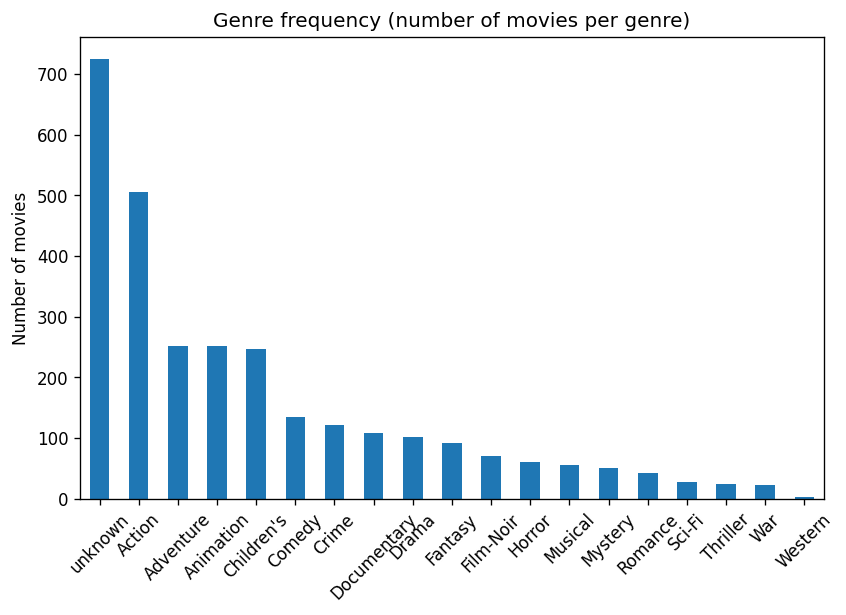

In [19]:
# Cell 6 — genre frequency
# load u.genre to get genre names
genre_map = {}
with open(os.path.join(base, "u.genre"), "r", encoding="latin-1") as f:
    for line in f:
        line = line.strip()
        if line:
            parts = line.split('|')
            genre_map[int(parts[1])] = parts[0]

# movies' genre flags are columns genre_0 ... genre_18 in same order as u.genre
genre_cols = [col for col in movies.columns if col.startswith("genre_")]
# sum of flags per genre
genre_counts = movies[genre_cols].sum().sort_values(ascending=False)

# map index numbers to names if we created consistent mapping:
# genre_cols order corresponds to indices 0..18
genre_names = [genre_map[i] for i in range(len(genre_cols))]
genre_counts.index = genre_names

print(genre_counts)
genre_counts.plot(kind='bar')
plt.title("Genre frequency (number of movies per genre)")
plt.ylabel("Number of movies")
plt.xticks(rotation=45)
plt.show()


## 7) Sparsity of user-item matrix

In [20]:
# Cell 7 — sparsity
n_users = ratings['userId'].nunique()
n_items = ratings['movieId'].nunique()
n_ratings = len(ratings)
total_cells = n_users * n_items
sparsity = 1 - (n_ratings / total_cells)

print(f"Users: {n_users}, Items: {n_items}, Ratings: {n_ratings}")
print(f"Matrix density (ratings/total): {n_ratings/total_cells:.6f}")
print(f"Matrix sparsity: {sparsity:.6f} (i.e. {sparsity*100:.4f}%)")


Users: 943, Items: 1682, Ratings: 100000
Matrix density (ratings/total): 0.063047
Matrix sparsity: 0.936953 (i.e. 93.6953%)


## 8) Handle missing data

In [22]:
# Cell 9 — check for missing values
print("ratings missing:\n", ratings.isnull().sum())
print("movies missing:\n", movies.isnull().sum())
print("users missing:\n", users.isnull().sum())

# There should be no missing values in u.data typical ML-100k; if any:
# Example of dropping rows with missing userId/movieId/rating
ratings = ratings.dropna(subset=['userId','movieId','rating']).astype({'userId':int,'movieId':int,'rating':float})


ratings missing:
 userId       0
movieId      0
rating       0
timestamp    0
dtype: int64
movies missing:
 movieId                  0
title                    0
release_date             1
video_release_date    1682
IMDb_URL                 3
genre_0                  0
genre_1                  0
genre_2                  0
genre_3                  0
genre_4                  0
genre_5                  0
genre_6                  0
genre_7                  0
genre_8                  0
genre_9                  0
genre_10                 0
genre_11                 0
genre_12                 0
genre_13                 0
genre_14                 0
genre_15                 0
genre_16                 0
genre_17                 0
genre_18                 0
dtype: int64
users missing:
 userId        0
age           0
gender        0
occupation    0
zip_code      0
dtype: int64


## 9) Create the user–item matrix (pivot)

In [23]:
# Cell 10 — create user-item matrix
# use filtered ratings if you applied filtering, else use ratings
df_for_matrix = ratings_filtered if 'ratings_filtered' in globals() else ratings

user_item_matrix = df_for_matrix.pivot_table(index='userId', columns='movieId', values='rating')

print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix.head()


User-item matrix shape: (943, 1682)


movieId,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,1658,1659,1660,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
userId,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,2.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,4.0,1.0,4.0,4.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,4.0,4.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 10) Save cleaned datasets & pivot for later

In [24]:
# Cell 12 — save cleaned files
out_dir = "data/processed"
os.makedirs(out_dir, exist_ok=True)

# save cleaned ratings (after optional filtering)
df_for_matrix.to_csv(os.path.join(out_dir, "ratings_clean.csv"), index=False)

# user-item matrix to csv (be careful: big)
user_item_matrix.to_csv(os.path.join(out_dir, "user_item_matrix.csv"))

# save movie metadata (useful for display)
movies[['movieId','title'] + genre_cols].to_csv(os.path.join(out_dir, "movies_meta.csv"), index=False)

print("Saved cleaned data to", out_dir)


Saved cleaned data to data/processed
